# Fase 1: Gaming vs Academic Performance

**Integrantes:** ________________________________

**Objetivo:** preparar un dataset limpio y reproducible para estudiar la asociación entre horas de videojuegos y rendimiento académico, considerando estudio y sueño. El dataset es simulado según su autor.

## Índice CRISP-DM

0. Configuración y carga — **COMPLETA**  
1. Comprensión del problema — **PENDIENTE**  
2. Comprensión y selección de los datos — **PENDIENTE**  
3. Limpieza y transformación — **COMPLETA**  
4. Análisis univariado y bivariado — **COMPLETA**  
5. Análisis descriptivo y exploratorio — **PENDIENTE**  
6. Conclusión de la Fase 1 — **PENDIENTE**

## Sección 0. Configuración y carga
Se importan las librerías permitidas, se definen rutas relativas, se carga `df_raw` y se crea la copia de trabajo `df`.

In [17]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd

print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

RAW_PATH = Path('../data/raw/Gaming_Academic_Performance_updated.csv')
CLEAN_PATH = Path('../data/processed/gaming_academic_clean.csv')
BITACORA_PATH = Path('../output/bitacora_limpieza.csv')
TOPE_NOTAS = 100

CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
BITACORA_PATH.parent.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(RAW_PATH)
n0 = len(df_raw)
hash_sha256 = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()

print(f'Dimensiones originales: {df_raw.shape}')
print('Tipos originales:')
print(df_raw.dtypes)
print(f'Hash SHA-256: {hash_sha256}')
print(f'n0: {n0}')

# Toda la limpieza se hace sobre esta copia; df_raw permanece sin modificar.
df = df_raw.copy()
registros_bitacora = []

def registrar(n_paso, paso, columna, revision_o_problema, registros_afectados, decision, fundamento):
    registros_bitacora.append({
        'n_paso': n_paso,
        'paso': paso,
        'columna': columna,
        'revision_o_problema': revision_o_problema,
        'registros_afectados': registros_afectados,
        'decision': decision,
        'fundamento': fundamento,
        'filas_despues': len(df)
    })

pandas: 2.3.3
numpy: 2.5.3
Dimensiones originales: (8000, 14)
Tipos originales:
student_id            int64
age                   int64
gender               object
gaming_hours        float64
study_hours         float64
sleep_hours         float64
attendance          float64
gaming_genre         object
social_activity     float64
device_usage        float64
reaction_time_ms    float64
addiction_score     float64
stress_level         object
grades              float64
dtype: object
Hash SHA-256: 3aece9216367cd67deaaade3f9b527e45e0fb20d22534280c26d858153fe1545
n0: 8000


## Sección 1. Comprensión del problema
PENDIENTE: se redacta en el documento de comprensión del problema y se resume aquí.

## Sección 2. Comprensión y selección de los datos
PENDIENTE: diccionario de datos, perfilado del dataset original (`df_raw`), evaluación de calidad, selección justificada y documentación de la fuente.

## Sección 3. Limpieza y transformación
Se documentan las revisiones, se transforma una copia y no se eliminan filas ni se imputan valores.

### 3.1 Revisiones previas
Se revisan faltantes, duplicados, unicidad, categorías, rangos, atípicos y consistencias sin modificar los datos.

In [18]:
# Faltantes por columna.
faltantes = df.isna().sum()
for columna, cantidad in faltantes.items():
    registrar('3.1', 'Revisiones previas', columna, 'Valores faltantes', int(cantidad), 'No imputar', 'Se conservan las filas y se documentan los faltantes.')

duplicadas_completas = int(df.duplicated().sum())
registrar('3.1', 'Revisiones previas', 'todas', 'Filas duplicadas completas', duplicadas_completas, 'No eliminar filas', 'La consigna exige conservar las 8000 filas.')
duplicadas_sin_id = int(df.drop(columns=['student_id']).duplicated().sum())
registrar('3.1', 'Revisiones previas', 'todas excepto student_id', 'Filas duplicadas ignorando student_id', duplicadas_sin_id, 'No eliminar filas', 'La revisión informa calidad sin alterar el dataset.')

id_notnull = int(df['student_id'].notna().sum())
id_nunique = int(df['student_id'].nunique())
id_unico = bool(df['student_id'].is_unique)
fallos_id = (n0 - id_notnull) + (n0 - id_nunique) + int(not id_unico)
registrar('3.1', 'Revisiones previas', 'student_id', 'Unicidad: notnull, nunique y is_unique', fallos_id, 'Conservar para revisar y descartar después', f'notnull={id_notnull}; nunique={id_nunique}; is_unique={id_unico}.')

nombres_duplicados = int(pd.Index(df.columns).duplicated().sum())
columnas_duplicadas = int(df.T.duplicated().sum())
registrar('3.1', 'Revisiones previas', 'nombres de columnas', 'Nombres de columna duplicados', nombres_duplicados, 'No modificar', 'Los nombres deben ser únicos.')
registrar('3.1', 'Revisiones previas', 'columnas', 'Columnas con contenido idéntico', columnas_duplicadas, 'No modificar', 'Se evita conservar información repetida sin cambiar el original.')

espacios_por_categoria = {}
variantes_por_categoria = {}
for columna in ['gender', 'gaming_genre', 'stress_level']:
    valores = df[columna].dropna().astype(str)
    con_espacios = int((valores != valores.str.strip()).sum())
    grupos_mayusculas = valores.groupby(valores.str.lower()).nunique()
    variantes = int((grupos_mayusculas > 1).sum())
    espacios_por_categoria[columna] = con_espacios
    variantes_por_categoria[columna] = variantes
    registrar('3.1', 'Revisiones previas', columna, 'Categorías, espacios sobrantes y variantes de mayúsculas', con_espacios + variantes, f'Valores únicos: {sorted(valores.unique().tolist())}', 'Se documentan las categorías antes de normalizar tipos.')
    print(f'{columna}: valores={sorted(valores.unique().tolist())}; espacios={con_espacios}; grupos_con_variantes_mayusculas={variantes}')

columnas_numericas = df.select_dtypes(include=np.number).columns
atipicos_por_columna = {}
for columna in columnas_numericas:
    minimo = df[columna].min()
    maximo = df[columna].max()
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    atipicos = int(((df[columna] < q1 - 1.5 * iqr) | (df[columna] > q3 + 1.5 * iqr)).sum())
    atipicos_por_columna[columna] = atipicos
    registrar('3.1', 'Revisiones previas', columna, 'Rango y atípicos por regla 1.5*IQR', atipicos, f'mín={minimo}; máx={maximo}', 'Se informa el rango y no se eliminan atípicos.')
    print(f'{columna}: mínimo={minimo}; máximo={maximo}; atípicos={atipicos}')

consistencias = {
    'device_usage >= gaming_hours': int((df['device_usage'] < df['gaming_hours']).sum()),
    'gaming_hours + study_hours + sleep_hours <= 24': int((df[['gaming_hours', 'study_hours', 'sleep_hours']].sum(axis=1) > 24).sum()),
    'attendance fuera de [0, 100]': int((~df['attendance'].between(0, 100)).sum()),
    'grades negativas': int((df['grades'] < 0).sum())
}
for revision, cantidad in consistencias.items():
    registrar('3.1', 'Revisiones previas', 'consistencia', revision, cantidad, 'Revisar sin eliminar filas', 'Las reglas de consistencia se informan antes de transformar.')
print('Consistencias:', consistencias)

def comparar(nombre, observado, esperado, tolerancia=0):
    estado = 'OK' if abs(observado - esperado) <= tolerancia else 'REVISAR'
    print(f'{nombre}: observado={observado}; esperado={esperado}; {estado}')

comparar('faltantes totales', int(faltantes.sum()), 0)
comparar('duplicadas completas', duplicadas_completas, 0)
comparar('duplicadas ignorando student_id', duplicadas_sin_id, 0)
comparar('student_id distintos', id_nunique, n0)
comparar('student_id único', int(id_unico), 1)
comparar('nombres de columna duplicados', nombres_duplicados, 0)
comparar('columnas con contenido idéntico', columnas_duplicadas, 0)
for columna in espacios_por_categoria:
    comparar(f'{columna} con espacios sobrantes', espacios_por_categoria[columna], 0)
    comparar(f'{columna} con variantes de mayúsculas', variantes_por_categoria[columna], 0)
comparar('atípicos totales', sum(atipicos_por_columna.values()), 0)
comparar('device_usage menor que gaming_hours', consistencias['device_usage >= gaming_hours'], 0)

gender: valores=['Female', 'Male', 'Other']; espacios=0; grupos_con_variantes_mayusculas=0
gaming_genre: valores=['Casual', 'FPS', 'RPG']; espacios=0; grupos_con_variantes_mayusculas=0
stress_level: valores=['High', 'Low', 'Medium']; espacios=0; grupos_con_variantes_mayusculas=0
student_id: mínimo=1; máximo=8000; atípicos=0
age: mínimo=16; máximo=24; atípicos=0
gaming_hours: mínimo=0.0; máximo=8.0; atípicos=0
study_hours: mínimo=1.0; máximo=10.0; atípicos=0
sleep_hours: mínimo=4.0; máximo=9.0; atípicos=0
attendance: mínimo=60.0; máximo=100.0; atípicos=0
social_activity: mínimo=0.0; máximo=5.0; atípicos=0
device_usage: mínimo=1.1; máximo=13.95; atípicos=0
reaction_time_ms: mínimo=183.26; máximo=347.87; atípicos=0
addiction_score: mínimo=-4.51; máximo=23.16; atípicos=0
grades: mínimo=0.0; máximo=118.63293578685628; atípicos=0
Consistencias: {'device_usage >= gaming_hours': 0, 'gaming_hours + study_hours + sleep_hours <= 24': 0, 'attendance fuera de [0, 100]': 0, 'grades negativas': 0}
fa

### 3.2 Indicador de registros ajustados
Se marca `grades` con más de dos decimales antes de redondear. La relación con los ajustes de horas es una hipótesis, no un hecho confirmado.

In [19]:
flag_ajustado = (df['grades'] - df['grades'].round(2)).abs() > 1e-9
df['flag_ajustado'] = flag_ajustado.astype(bool)
cantidad_ajustados = int(flag_ajustado.sum())
suma_horas = df[['gaming_hours', 'study_hours', 'sleep_hours']].sum(axis=1)
promedio_ajustadas = suma_horas[flag_ajustado].mean()
promedio_no_ajustadas = suma_horas[~flag_ajustado].mean()
print(f'Registros con más de dos decimales en grades: {cantidad_ajustados}')
print(f'Media de horas totales en filas ajustadas: {promedio_ajustadas:.4f}')
print(f'Media de horas totales en filas no ajustadas: {promedio_no_ajustadas:.4f}')
registrar('3.2', 'Indicador de registros ajustados', 'grades', 'Más de dos decimales antes del redondeo', cantidad_ajustados, 'Crear flag_ajustado', 'La relación con ajustes de horas es una hipótesis y se conserva como indicador.')
comparar('grades con más de dos decimales', cantidad_ajustados, 1671, tolerancia=100)

Registros con más de dos decimales en grades: 1671
Media de horas totales en filas ajustadas: 18.8327
Media de horas totales en filas no ajustadas: 15.2625
grades con más de dos decimales: observado=1671; esperado=1671; OK


### 3.3 Limpieza de `grades`
Se conserva `grades_original`, se marca `flag_grades_gt100` y se limita `grades` a 100 bajo el supuesto de una escala 0-100.

In [20]:
grades_original = df['grades'].copy()
flag_grades_gt100 = df['grades'] > TOPE_NOTAS
cantidad_gt100 = int(flag_grades_gt100.sum())
cantidad_100 = int((df['grades'] == 100).sum())
cantidad_0 = int((df['grades'] == 0).sum())
print(f'Notas mayores que 100: {cantidad_gt100}')
print(f'Notas exactamente iguales a 100: {cantidad_100}')
print(f'Notas exactamente iguales a 0: {cantidad_0}')
print(f'Máximo original de grades: {grades_original.max()}')
comparar('máximo original de grades', float(grades_original.max()), 118.63, tolerancia=0.01)

df['grades_original'] = grades_original
df['flag_grades_gt100'] = flag_grades_gt100.astype(bool)
df['grades'] = df['grades'].clip(upper=TOPE_NOTAS)
registrar('3.3', 'Limpieza de grades', 'grades', 'Valores superiores al tope de notas', cantidad_gt100, 'Aplicar clip superior en 100 y conservar grades_original', 'Conserva las 8000 filas, sigue la escala 0-100 asumida y permite análisis de sensibilidad posterior.')
comparar('grades mayores que 100', cantidad_gt100, 134, tolerancia=20)
comparar('grades iguales a 100', cantidad_100, 439, tolerancia=20)
comparar('grades iguales a 0', cantidad_0, 1)

Notas mayores que 100: 134
Notas exactamente iguales a 100: 439
Notas exactamente iguales a 0: 1
Máximo original de grades: 118.63293578685628
máximo original de grades: observado=118.63293578685628; esperado=118.63; OK
grades mayores que 100: observado=134; esperado=134; OK
grades iguales a 100: observado=439; esperado=439; OK
grades iguales a 0: observado=1; esperado=1; OK


### 3.4 Tipos y categorías
Se quitan espacios externos y se convierten las categorías; `stress_level` queda ordenada como Low < Medium < High.

In [21]:
for columna in ['gender', 'stress_level', 'gaming_genre']:
    antes = df[columna].copy()
    df[columna] = df[columna].str.strip()
    cambiaron = int((antes != df[columna]).sum())
    registrar('3.4', 'Tipos y categorías', columna, 'Espacios externos', cambiaron, 'Aplicar str.strip()', 'Normaliza categorías sin cambiar su significado.')
    print(f'{columna}: valores modificados por strip={cambiaron}')

df['gender'] = df['gender'].astype('category')
stress_categorias = ['Low', 'Medium', 'High']
df['stress_level'] = pd.Categorical(df['stress_level'], categories=stress_categorias, ordered=True)
age_entero = bool(np.all(df['age'].dropna() == df['age'].dropna().astype(int)))
registrar('3.4', 'Tipos y categorías', 'age', 'Verificación de tipo entero', 0 if age_entero else 1, 'Conservar tipo entero si se cumple', 'La edad está definida como años enteros.')
print(f'age es entero: {age_entero}')

gender: valores modificados por strip=0
stress_level: valores modificados por strip=0
gaming_genre: valores modificados por strip=0
age es entero: True


### 3.5 Variables derivadas
Se supone que `device_usage` incluye el juego, por lo que se crea `uso_no_gaming`. Estas tres variables no deben entrar juntas en una regresión. `gaming_cat` usa terciles; cortes fijos 2 y 5 horas son una alternativa.

In [22]:
device_menor = int((df['device_usage'] < df['gaming_hours']).sum())
print(f'Filas con device_usage < gaming_hours: {device_menor}')
registrar('3.5', 'Variables derivadas', 'uso_no_gaming', 'device_usage >= gaming_hours', device_menor, 'Crear diferencia solo si la consistencia se mantiene', 'Supuesto: device_usage incluye gaming_hours.')

df['uso_no_gaming'] = df['device_usage'] - df['gaming_hours']
df['gaming_cat'], cortes_gaming = pd.qcut(df['gaming_hours'], q=3, labels=['Bajo', 'Medio', 'Alto'], retbins=True)
df['gaming_cat'] = pd.Categorical(df['gaming_cat'], categories=['Bajo', 'Medio', 'Alto'], ordered=True)
tamanos_gaming = df['gaming_cat'].value_counts(sort=False)
print(f'Cortes de gaming_hours: {cortes_gaming}')
print('Tamaño de cada grupo:')
print(tamanos_gaming)
comparar('cortes de gaming_hours: tercil 1', float(cortes_gaming[1]), 2.8, tolerancia=0.1)
comparar('cortes de gaming_hours: tercil 2', float(cortes_gaming[2]), 5.46, tolerancia=0.1)
registrar('3.5', 'Variables derivadas', 'gaming_cat', 'Cortes por terciles', len(cortes_gaming) - 1, f'Cortes: {cortes_gaming.tolist()}', 'Agrupa en Bajo, Medio y Alto para comparación descriptiva; los cortes fijos 2 y 5 horas son una alternativa.')

Filas con device_usage < gaming_hours: 0
Cortes de gaming_hours: [0.   2.8  5.46 8.  ]
Tamaño de cada grupo:
gaming_cat
Bajo     2671
Medio    2667
Alto     2662
Name: count, dtype: int64
cortes de gaming_hours: tercil 1: observado=2.8; esperado=2.8; OK
cortes de gaming_hours: tercil 2: observado=5.46; esperado=5.46; OK


### 3.6 Redondeo
Se redondean a dos decimales las columnas float, excepto `grades_original`.

In [23]:
columnas_float = df.select_dtypes(include=['float64', 'float32']).columns.tolist()
columnas_float = [columna for columna in columnas_float if columna != 'grades_original']
for columna in columnas_float:
    df[columna] = df[columna].round(2)
excesos_decimales = int(sum(((df[columna] - df[columna].round(2)).abs() > 1e-9).sum() for columna in columnas_float))
comparar('valores float con más de dos decimales después del redondeo', excesos_decimales, 0)
registrar('3.6', 'Redondeo', ', '.join(columnas_float), 'Valores float con más de dos decimales', cantidad_ajustados, 'Redondear a dos decimales', 'Facilita lectura y mantiene grades_original sin alterar.')

valores float con más de dos decimales después del redondeo: observado=0; esperado=0; OK


### 3.7 Descarte de columnas
Se calcula la evidencia y se descartan identificador, variables redundantes o fuera del alcance.

In [24]:
student_id_secuencial = bool((df_raw['student_id'] == np.arange(1, n0 + 1)).all())
corr_reaction = df_raw['gaming_hours'].corr(df_raw['reaction_time_ms'])
corr_addiction = df_raw['gaming_hours'].corr(df_raw['addiction_score'])
negativos_addiction = int((df_raw['addiction_score'] < 0).sum())
print(f'student_id es fila + 1: {student_id_secuencial}')
print(f'Correlación gaming_hours/reaction_time_ms: {corr_reaction:.4f}')
print(f'Correlación gaming_hours/addiction_score: {corr_addiction:.4f}')
print(f'addiction_score negativos en el original: {negativos_addiction}')
comparar('correlación gaming_hours/reaction_time_ms', float(corr_reaction), -0.94, tolerancia=0.01)
comparar('correlación gaming_hours/addiction_score', float(corr_addiction), 0.91, tolerancia=0.01)
comparar('addiction_score negativos', negativos_addiction, 107)
registrar('3.7', 'Descarte de columnas', 'reaction_time_ms', 'Correlación con gaming_hours', 0, f'r={corr_reaction:.4f}', 'Redundante con gaming_hours y fuera del objetivo definido.')
registrar('3.7', 'Descarte de columnas', 'addiction_score', 'Valores negativos y correlación con gaming_hours', negativos_addiction, f'r={corr_addiction:.4f}; negativos={negativos_addiction}', 'Escala no documentada; los negativos son anomalías del original y no se corrigen porque la columna se descarta.')

COLUMNAS_DESCARTADAS = {
    'student_id': 'Identificador único sin información analítica; coincide con número de fila + 1.',
    'reaction_time_ms': 'Redundante con gaming_hours y no vinculada al objetivo del proyecto.',
    'gaming_genre': 'Fuera del alcance: el análisis se centra en horas de juego, no tipo de juego.',
    'addiction_score': 'Escala no documentada, valores negativos y casi redundante con gaming_hours.'
}
for columna, justificacion in COLUMNAS_DESCARTADAS.items():
    registrar('3.7', 'Descarte de columnas', columna, 'Columna fuera del dataset analítico final', n0, 'Descartar', justificacion)
df = df.drop(columns=list(COLUMNAS_DESCARTADAS))

COLUMNAS_CONSERVADAS = ['age', 'gender', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'stress_level', 'grades']
columnas_finales = ['age', 'gender', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'uso_no_gaming', 'stress_level', 'gaming_cat', 'grades', 'grades_original', 'flag_grades_gt100', 'flag_ajustado']
df = df[columnas_finales]
print(f'Columnas descartadas: {list(COLUMNAS_DESCARTADAS)}')
print(f'Columnas conservadas explícitamente: {COLUMNAS_CONSERVADAS}')

student_id es fila + 1: True
Correlación gaming_hours/reaction_time_ms: -0.9389
Correlación gaming_hours/addiction_score: 0.9086
addiction_score negativos en el original: 107
correlación gaming_hours/reaction_time_ms: observado=-0.9389431437392204; esperado=-0.94; OK
correlación gaming_hours/addiction_score: observado=0.9085989038090079; esperado=0.91; OK
addiction_score negativos: observado=107; esperado=107; OK
Columnas descartadas: ['student_id', 'reaction_time_ms', 'gaming_genre', 'addiction_score']
Columnas conservadas explícitamente: ['age', 'gender', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'stress_level', 'grades']


### 3.8 Validaciones finales
Se comprueba con `assert` la forma, columnas, tipos, flags, rangos y ausencia de duplicados o nulos.

In [25]:
columnas_finales = ['age', 'gender', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'uso_no_gaming', 'stress_level', 'gaming_cat', 'grades', 'grades_original', 'flag_grades_gt100', 'flag_ajustado']
assert len(df) == n0
assert not df.isna().any().any()
assert df['grades'].between(0, 100).all()
assert (df['uso_no_gaming'] >= 0).all()
assert not df.duplicated().any()
assert df.columns.tolist() == columnas_finales
assert isinstance(df['stress_level'].dtype, pd.CategoricalDtype) and df['stress_level'].cat.ordered
assert isinstance(df['gaming_cat'].dtype, pd.CategoricalDtype) and df['gaming_cat'].cat.ordered
assert df['flag_grades_gt100'].dtype == bool
assert df['flag_ajustado'].dtype == bool
assert df_raw.shape == (8000, 14)
print('Validaciones finales: OK')

Validaciones finales: OK


### 3.9 Exportación y resumen
Se guardan el dataset limpio y la bitácora, y se verifica que el CSV pueda recargarse con la misma estructura.

In [26]:
bitacora = pd.DataFrame(registros_bitacora, columns=['n_paso', 'paso', 'columna', 'revision_o_problema', 'registros_afectados', 'decision', 'fundamento', 'filas_despues'])
df.to_csv(CLEAN_PATH, index=False, encoding='utf-8')
bitacora.to_csv(BITACORA_PATH, index=False, encoding='utf-8')

df_guardado = pd.read_csv(CLEAN_PATH)
assert df_guardado.shape == (n0, len(columnas_finales))
assert df_guardado.columns.tolist() == columnas_finales
print(f'Dataset guardado en: {CLEAN_PATH}')
print(f'Bitácora guardada en: {BITACORA_PATH}')
print(f'Filas: {n0} antes / {len(df)} después')
print(f'Columnas: {len(df_raw.columns)} antes / {len(df.columns)} después')
print(f'Columnas eliminadas: {list(COLUMNAS_DESCARTADAS)}')
print('Columnas creadas: uso_no_gaming, gaming_cat, grades_original, flag_grades_gt100, flag_ajustado')
print('Bitácora completa:')
display(bitacora)

Dataset guardado en: ..\data\processed\gaming_academic_clean.csv
Bitácora guardada en: ..\output\bitacora_limpieza.csv
Filas: 8000 antes / 8000 después
Columnas: 14 antes / 15 después
Columnas eliminadas: ['student_id', 'reaction_time_ms', 'gaming_genre', 'addiction_score']
Columnas creadas: uso_no_gaming, gaming_cat, grades_original, flag_grades_gt100, flag_ajustado
Bitácora completa:


,n_paso,paso,columna,revision_o_problema,registros_afectados,decision,fundamento,filas_despues
0,3.1,Revisiones previas,student_id,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
1,3.1,Revisiones previas,age,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
2,3.1,Revisiones previas,gender,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
3,3.1,Revisiones previas,gaming_hours,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
4,3.1,Revisiones previas,study_hours,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
5,3.1,Revisiones previas,sleep_hours,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
6,3.1,Revisiones previas,attendance,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
7,3.1,Revisiones previas,gaming_genre,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
8,3.1,Revisiones previas,social_activity,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000
9,3.1,Revisiones previas,device_usage,Valores faltantes,0,No imputar,Se conservan las filas y se documentan los fal...,8000


#### Recarga posterior del dataset limpio
Las secciones 4 y 5 trabajarán directamente con el DataFrame `df` limpio que queda en memoria, sin recargarlo desde el CSV. El CSV se exporta como entregable y para reproducibilidad.

Si se necesita recargarlo en otra sesión, se deben restaurar las categorías ordenadas así:

```python
df = pd.read_csv('../data/processed/gaming_academic_clean.csv')
df['stress_level'] = pd.Categorical(df['stress_level'], categories=['Low', 'Medium', 'High'], ordered=True)
df['gaming_cat'] = pd.Categorical(df['gaming_cat'], categories=['Bajo', 'Medio', 'Alto'], ordered=True)
```

## Sección 4. Análisis univariado y bivariado

Esta sección describe la distribución individual de las variables y las relaciones entre ellas. Todos los cálculos se hacen sobre `df`, que ya fue limpiado en la sección 3; el dataset original y el archivo CSV no se modifican.

**Criterio de lectura:** la media resume bien una variable cuando la distribución es aproximadamente simétrica y no presenta valores extremos dominantes. Cuando hay asimetría o una diferencia importante entre media y mediana, se prioriza la mediana y el rango intercuartílico porque son medidas más robustas.

**Análisis temporal:** el dataset no contiene una fecha, hora ni otra variable temporal identificable. Por esa razón, no corresponde calcular media móvil, estacionalidad semanal/mensual ni quiebres temporales; esta ausencia se deja documentada en la conclusión de la sección.

### 4.0 Análisis univariado

El análisis univariado estudia una sola variable por vez. En las variables numéricas se resumen el centro, la dispersión, la forma y los valores extremos mediante tablas, histogramas y diagramas de caja. En las variables categóricas se cuentan las categorías y se calcula su proporción mediante frecuencias, porcentajes y gráficos de barras.

Resumen univariado de variables numéricas:


,media,mediana,moda,desvio_estandar,coeficiente_variacion_%,minimo,maximo,rango_intercuartilico,percentil_5,percentil_25,percentil_50,percentil_75,percentil_95,asimetria,curtosis_exceso
age,19.984,20.000,16.00,2.587,12.946,16.0,24.000,4.000,16.00,18.000,20.000,22.000,24.00,-0.002,-1.233
gaming_hours,4.077,4.130,5.97,2.297,56.350,0.0,8.000,3.910,0.42,2.130,4.130,6.040,7.57,-0.066,-1.186
study_hours,5.449,5.460,1.67,2.560,46.975,1.0,10.000,4.400,1.47,3.240,5.460,7.640,9.46,0.010,-1.189
sleep_hours,6.483,6.500,7.37,1.432,22.087,4.0,9.000,2.450,4.24,5.240,6.500,7.690,8.72,-0.000,-1.190
attendance,79.887,79.695,71.40,11.580,14.496,60.0,100.000,20.320,62.03,69.780,79.695,90.100,97.95,0.021,-1.213
social_activity,2.508,2.500,2.26,1.441,57.466,0.0,5.000,2.472,0.26,1.288,2.500,3.760,4.75,-0.004,-1.198
device_usage,7.586,7.610,7.68,2.710,35.723,1.1,13.950,4.040,3.09,5.560,7.610,9.600,12.08,-0.011,-0.691
uso_no_gaming,3.510,3.530,3.09,1.439,41.006,1.0,6.660,2.490,1.25,2.270,3.530,4.760,5.73,-0.020,-1.190
grades,66.080,67.070,100.00,22.253,33.675,0.0,100.000,34.112,27.36,49.880,67.070,83.992,100.00,-0.283,-0.708
grades_original,66.181,67.070,100.00,22.422,33.880,0.0,118.633,34.112,27.36,49.880,67.070,83.992,100.00,-0.252,-0.686


Criterio de centro recomendado: |asimetría| > 1 o diferencia media-mediana > 10% indica posible asimetría relevante.


,media,mediana,asimetria,curtosis_exceso,diferencia_media_mediana_%,centro_recomendado
age,19.984,20.000,-0.002,-1.233,0.082,Media y desvío estándar
gaming_hours,4.077,4.130,-0.066,-1.186,1.294,Media y desvío estándar
study_hours,5.449,5.460,0.010,-1.189,0.206,Media y desvío estándar
sleep_hours,6.483,6.500,-0.000,-1.190,0.263,Media y desvío estándar
attendance,79.887,79.695,0.021,-1.213,0.240,Media y desvío estándar
social_activity,2.508,2.500,-0.004,-1.198,0.312,Media y desvío estándar
device_usage,7.586,7.610,-0.011,-0.691,0.311,Media y desvío estándar
uso_no_gaming,3.510,3.530,-0.020,-1.190,0.574,Media y desvío estándar
grades,66.080,67.070,-0.283,-0.708,1.475,Media y desvío estándar
grades_original,66.181,67.070,-0.252,-0.686,1.326,Media y desvío estándar


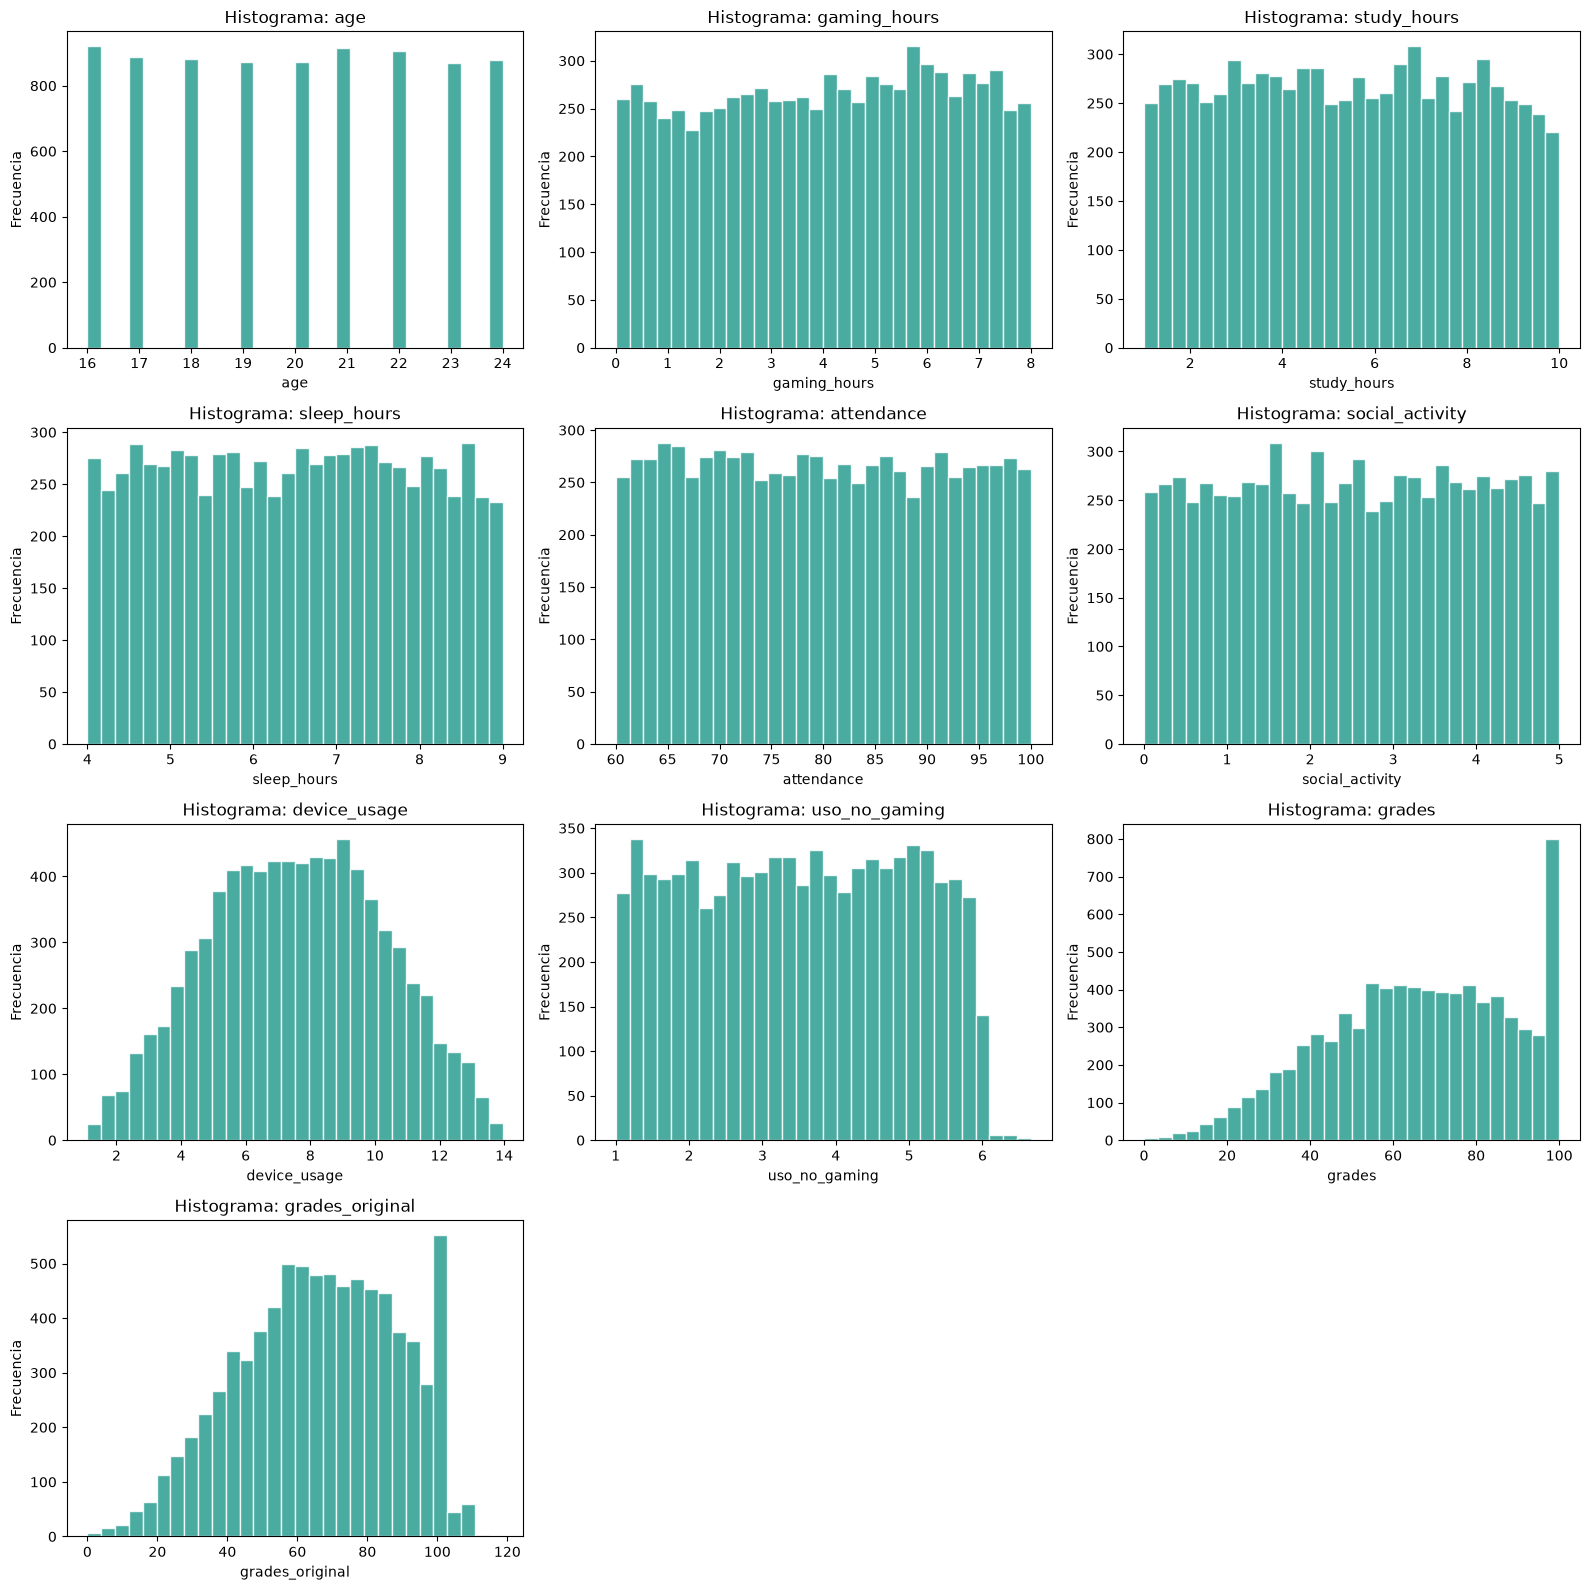

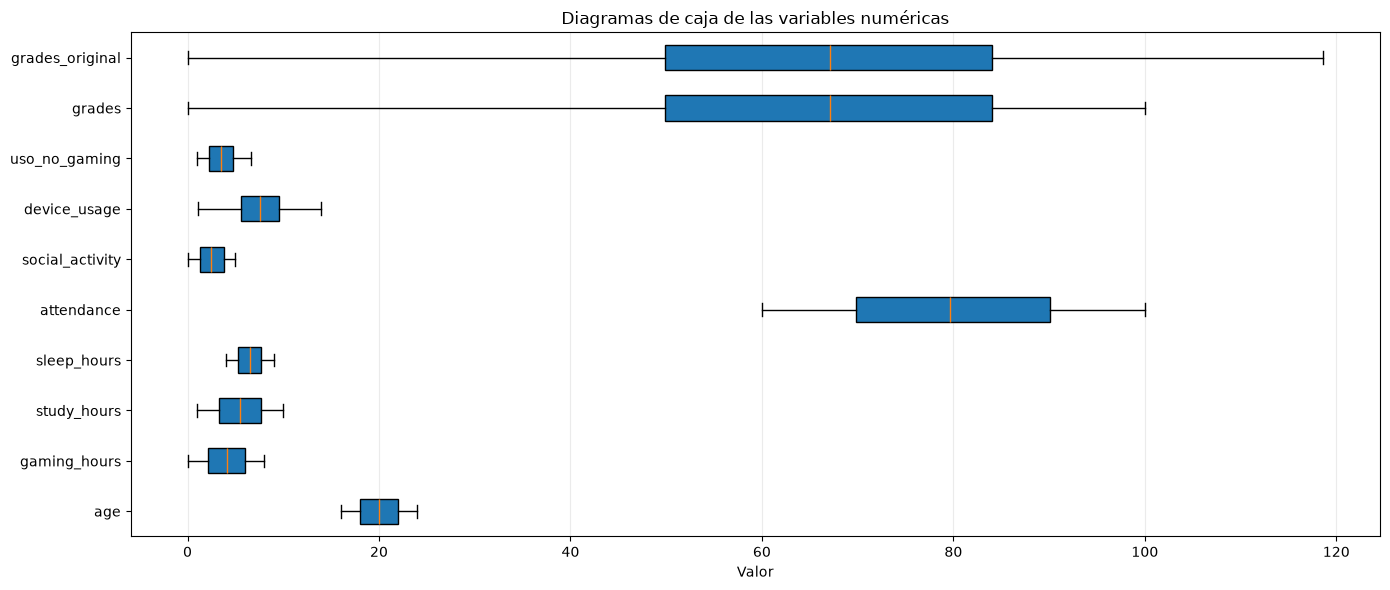

In [28]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Se excluyen los flags porque son indicadores booleanos, no variables numéricas de medición.
columnas_numericas = [
    columna for columna in df.select_dtypes(include=np.number).columns
    if columna not in ['flag_grades_gt100', 'flag_ajustado']
]

# Estos estadísticos describen centro, dispersión, forma y extremos de cada variable.
def moda_principal(serie):
    modas = serie.mode(dropna=True)
    return modas.iloc[0] if len(modas) else np.nan

def coeficiente_variacion(serie):
    media = serie.mean()
    return np.nan if np.isclose(media, 0) else serie.std(ddof=1) / abs(media) * 100

resumen_numerico = pd.DataFrame(index=columnas_numericas)
resumen_numerico['media'] = df[columnas_numericas].mean()
resumen_numerico['mediana'] = df[columnas_numericas].median()
resumen_numerico['moda'] = [moda_principal(df[columna]) for columna in columnas_numericas]
resumen_numerico['desvio_estandar'] = df[columnas_numericas].std()
resumen_numerico['coeficiente_variacion_%'] = [coeficiente_variacion(df[columna]) for columna in columnas_numericas]
resumen_numerico['minimo'] = df[columnas_numericas].min()
resumen_numerico['maximo'] = df[columnas_numericas].max()
resumen_numerico['rango_intercuartilico'] = df[columnas_numericas].quantile(0.75) - df[columnas_numericas].quantile(0.25)
for porcentaje in [5, 25, 50, 75, 95]:
    resumen_numerico[f'percentil_{porcentaje}'] = df[columnas_numericas].quantile(porcentaje / 100)
resumen_numerico['asimetria'] = df[columnas_numericas].skew()
resumen_numerico['curtosis_exceso'] = df[columnas_numericas].kurt()

print('Resumen univariado de variables numéricas:')
display(resumen_numerico.round(3))

# La diferencia entre media y mediana, junto con la asimetría, orienta qué medida de centro conviene reportar.
resumen_numerico['diferencia_media_mediana_%'] = (
    (resumen_numerico['media'] - resumen_numerico['mediana']).abs()
    / resumen_numerico['mediana'].replace(0, np.nan).abs() * 100
)
resumen_numerico['centro_recomendado'] = np.where(
    (resumen_numerico['asimetria'].abs() > 1)
    | (resumen_numerico['diferencia_media_mediana_%'] > 10),
    'Mediana e IQR',
    'Media y desvío estándar'
)
print('Criterio de centro recomendado: |asimetría| > 1 o diferencia media-mediana > 10% indica posible asimetría relevante.')
display(resumen_numerico[['media', 'mediana', 'asimetria', 'curtosis_exceso', 'diferencia_media_mediana_%', 'centro_recomendado']].round(3))

# Histogramas y cajas muestran forma, concentración, dispersión y posibles valores extremos.
filas = math.ceil(len(columnas_numericas) / 3)
fig, ejes = plt.subplots(filas, 3, figsize=(16, 4 * filas))
ejes = np.atleast_1d(ejes).ravel()
for eje, columna in zip(ejes, columnas_numericas):
    eje.hist(df[columna], bins=30, color='#2a9d8f', edgecolor='white', alpha=0.85)
    eje.set_title(f'Histograma: {columna}')
    eje.set_xlabel(columna)
    eje.set_ylabel('Frecuencia')
for eje in ejes[len(columnas_numericas):]:
    eje.set_visible(False)
plt.tight_layout()
plt.show()

fig, eje = plt.subplots(figsize=(14, 6))
eje.boxplot([df[columna].dropna() for columna in columnas_numericas], tick_labels=columnas_numericas, orientation='horizontal', patch_artist=True)
eje.set_title('Diagramas de caja de las variables numéricas')
eje.set_xlabel('Valor')
eje.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

### 4.1 Análisis univariado de variables categóricas

Este bloque sigue siendo univariado porque analiza cada variable categórica por separado: `gender`, `stress_level` y `gaming_cat`. Las frecuencias absolutas indican cuántos registros pertenecen a cada categoría y las relativas muestran su peso sobre el total. La concentración del 20% toma las categorías más frecuentes que representan aproximadamente el 20% de las categorías disponibles y calcula qué proporción de observaciones acumulan. Esto permite detectar categorías dominantes.

Frecuencias de gender:


,frecuencia,porcentaje_%
gender,,
Male,3904,48.80
Female,3803,47.54
Other,293,3.66


Frecuencias de stress_level:


,frecuencia,porcentaje_%
stress_level,,
Medium,4247,53.09
Low,2743,34.29
High,1010,12.62


Frecuencias de gaming_cat:


,frecuencia,porcentaje_%
gaming_cat,,
Bajo,2671,33.39
Medio,2667,33.34
Alto,2662,33.28


Concentración: participación de las categorías más frecuentes que representan el 20% de las categorías:


,variable,categorias_totales,categorias_tomadas_20%,categorias_principales,porcentaje_observaciones_acumulado_%
0,gender,3,1,Male,48.80
1,stress_level,3,1,Medium,53.09
2,gaming_cat,3,1,Bajo,33.39


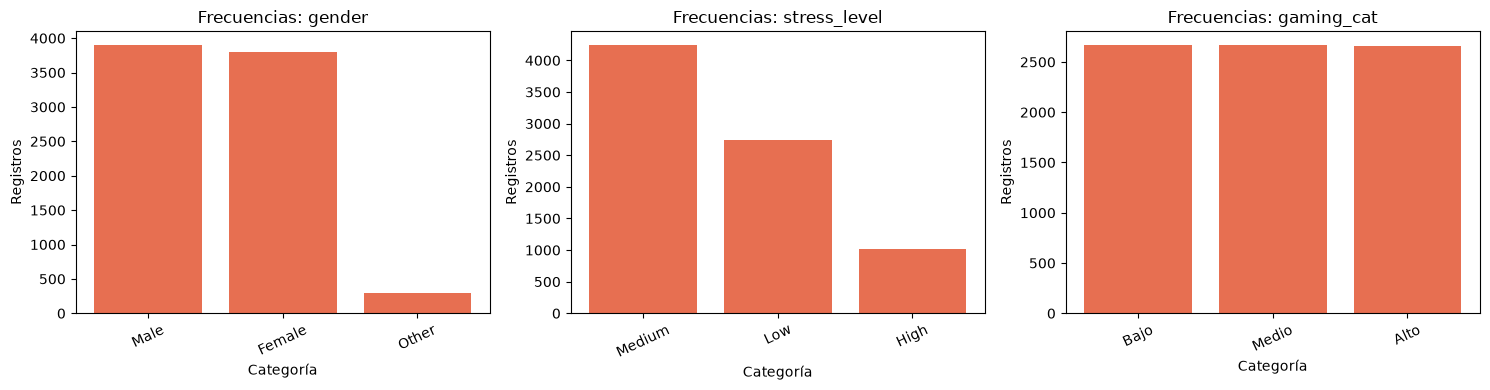

In [13]:
columnas_categoricas = ['gender', 'stress_level', 'gaming_cat']

# Se calcula una tabla por variable para conocer cantidad y porcentaje de cada categoría.
frecuencias_categoricas = {}
concentracion_20 = []
for columna in columnas_categoricas:
    frecuencias = df[columna].value_counts(dropna=False).rename('frecuencia').to_frame()
    frecuencias['porcentaje_%'] = frecuencias['frecuencia'] / len(df) * 100
    frecuencias_categoricas[columna] = frecuencias
    print(f'Frecuencias de {columna}:')
    display(frecuencias.round(2))

    # ceil evita redondear a cero cuando una variable tiene pocas categorías.
    cantidad_categorias_20 = max(1, math.ceil(df[columna].nunique() * 0.20))
    principales = frecuencias.head(cantidad_categorias_20)
    concentracion_20.append({
        'variable': columna,
        'categorias_totales': df[columna].nunique(),
        'categorias_tomadas_20%': cantidad_categorias_20,
        'categorias_principales': ', '.join(map(str, principales.index)),
        'porcentaje_observaciones_acumulado_%': principales['porcentaje_%'].sum()
    })

print('Concentración: participación de las categorías más frecuentes que representan el 20% de las categorías:')
display(pd.DataFrame(concentracion_20).round(2))

# Los gráficos de barras facilitan comparar rápidamente la frecuencia de cada categoría.
fig, ejes = plt.subplots(1, len(columnas_categoricas), figsize=(15, 4))
for eje, columna in zip(ejes, columnas_categoricas):
    frecuencias = frecuencias_categoricas[columna]
    eje.bar(frecuencias.index.astype(str), frecuencias['frecuencia'], color='#e76f51')
    eje.set_title(f'Frecuencias: {columna}')
    eje.set_xlabel('Categoría')
    eje.set_ylabel('Registros')
    eje.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### 4.2 Análisis bivariado: numérica frente a numérica

El análisis bivariado estudia dos variables al mismo tiempo para describir una relación, asociación o diferencia entre ellas. En este bloque se comparan dos variables numéricas mediante diagramas de dispersión y correlaciones. La correlación de Pearson mide asociación lineal y la de Spearman mide asociación monótona basada en rangos. Compararlas ayuda a distinguir una relación lineal de una relación que puede ser creciente/decreciente pero no lineal. La matriz de correlaciones resume todas las asociaciones numéricas; no implica causalidad.

Correlación de Pearson:


,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,uso_no_gaming,grades,grades_original
age,1.000,0.004,0.011,0.009,0.011,0.008,-0.000,-0.006,0.008,0.008
gaming_hours,0.004,1.000,-0.022,-0.010,-0.000,0.007,0.847,-0.001,-0.558,-0.557
study_hours,0.011,-0.022,1.000,0.004,-0.009,-0.011,-0.017,0.003,0.734,0.734
sleep_hours,0.009,-0.010,0.004,1.000,-0.031,-0.023,-0.000,0.016,0.245,0.246
attendance,0.011,-0.000,-0.009,-0.031,1.000,0.008,-0.005,-0.009,0.130,0.131
social_activity,0.008,0.007,-0.011,-0.023,0.008,1.000,0.006,-0.001,-0.019,-0.019
device_usage,-0.000,0.847,-0.017,-0.000,-0.005,0.006,1.000,0.531,-0.469,-0.468
uso_no_gaming,-0.006,-0.001,0.003,0.016,-0.009,-0.001,0.531,1.000,0.007,0.007
grades,0.008,-0.558,0.734,0.245,0.130,-0.019,-0.469,0.007,1.000,0.999
grades_original,0.008,-0.557,0.734,0.246,0.131,-0.019,-0.468,0.007,0.999,1.000


Correlación de Spearman:


,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,uso_no_gaming,grades,grades_original
age,1.000,0.004,0.011,0.009,0.011,0.008,-0.001,-0.006,0.010,0.010
gaming_hours,0.004,1.000,-0.022,-0.011,0.000,0.007,0.853,-0.001,-0.547,-0.547
study_hours,0.011,-0.022,1.000,0.005,-0.009,-0.011,-0.017,0.003,0.742,0.742
sleep_hours,0.009,-0.011,0.005,1.000,-0.031,-0.023,0.002,0.015,0.239,0.238
attendance,0.011,0.000,-0.009,-0.031,1.000,0.008,-0.007,-0.009,0.126,0.126
social_activity,0.008,0.007,-0.011,-0.023,0.008,1.000,0.005,-0.001,-0.017,-0.017
device_usage,-0.001,0.853,-0.017,0.002,-0.007,0.005,1.000,0.507,-0.465,-0.464
uso_no_gaming,-0.006,-0.001,0.003,0.015,-0.009,-0.001,0.507,1.000,0.005,0.006
grades,0.010,-0.547,0.742,0.239,0.126,-0.017,-0.465,0.005,1.000,1.000
grades_original,0.010,-0.547,0.742,0.238,0.126,-0.017,-0.464,0.006,1.000,1.000


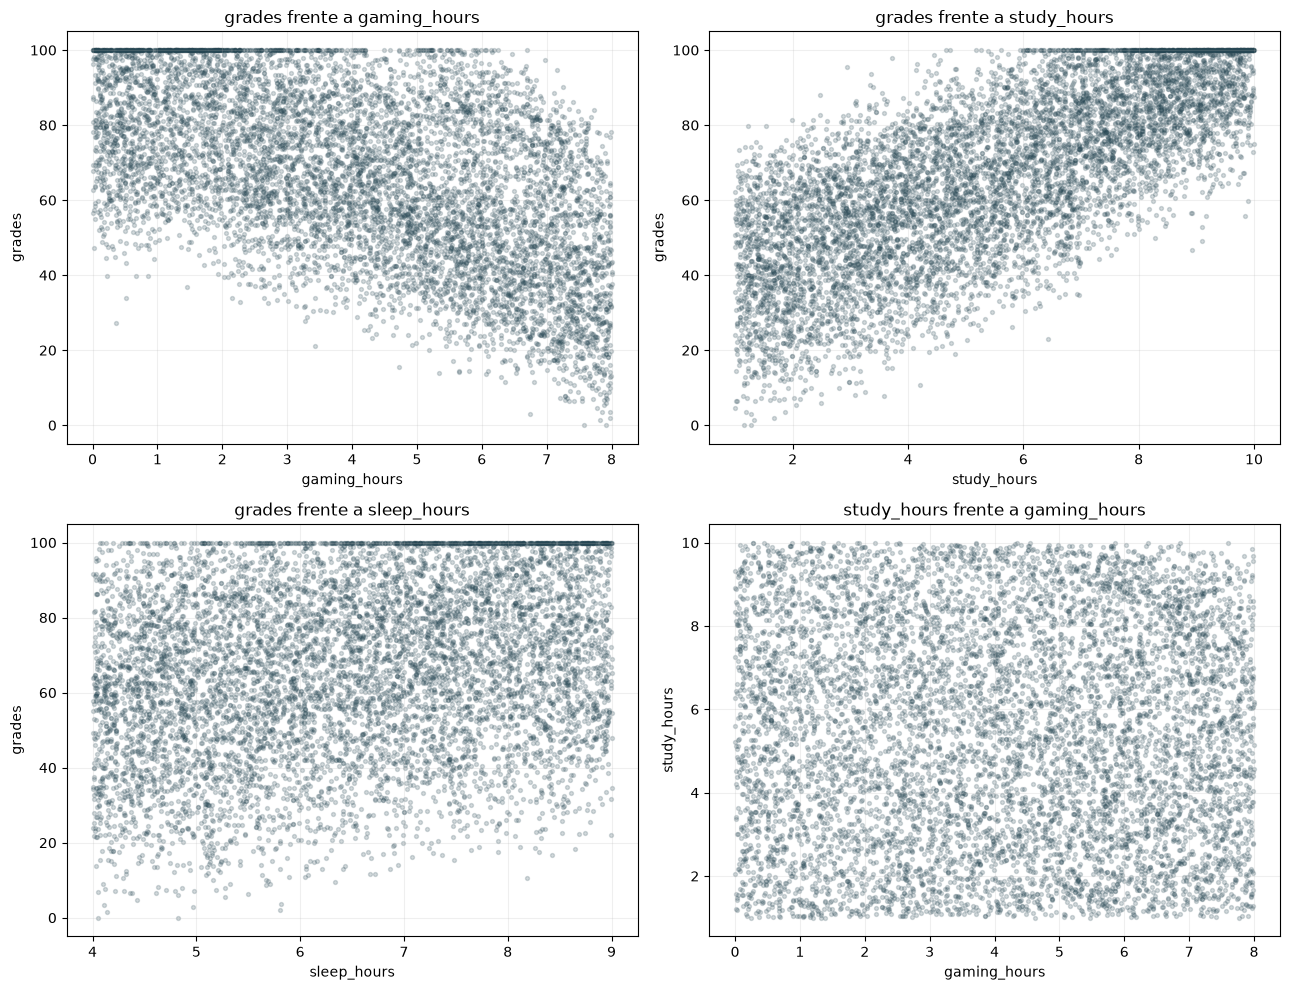

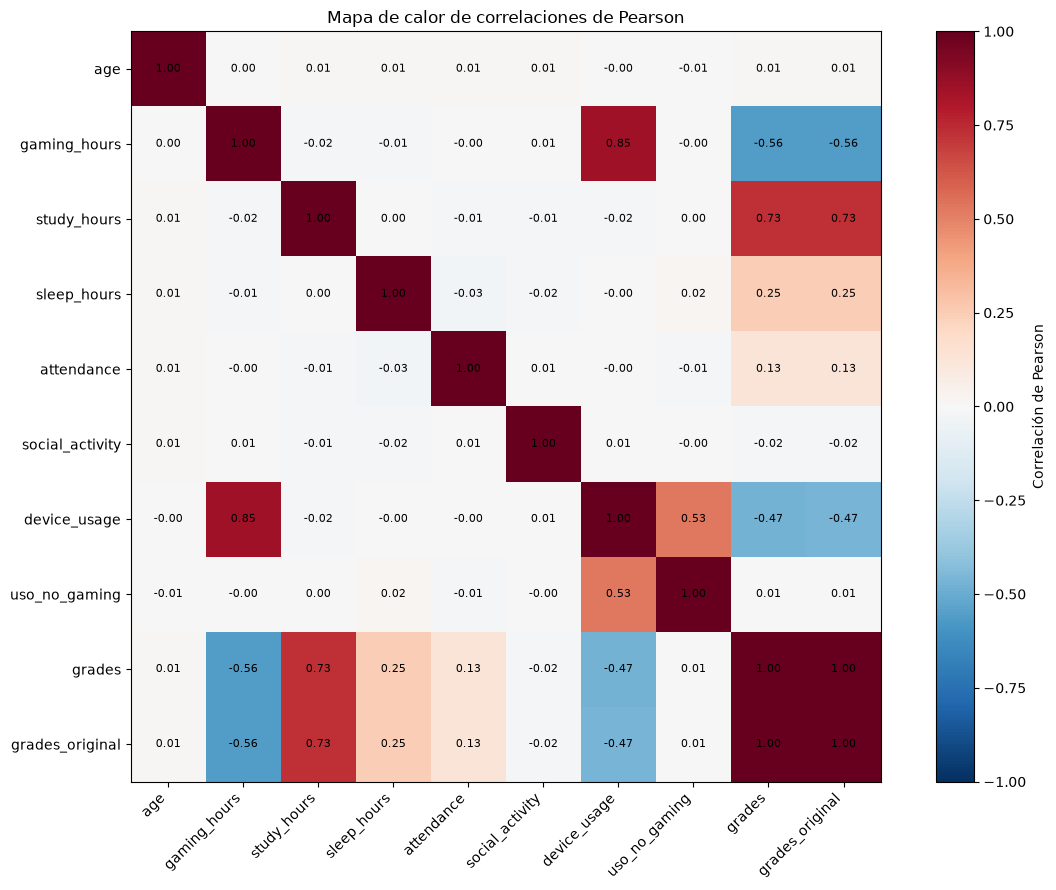

Pares con mayor asociación absoluta según Pearson:


,variable_1,variable_2,pearson,spearman
44,grades,grades_original,0.999,1.000
13,gaming_hours,device_usage,0.847,0.853
23,study_hours,grades_original,0.734,0.742
22,study_hours,grades,0.734,0.742
15,gaming_hours,grades,-0.558,-0.547
16,gaming_hours,grades_original,-0.557,-0.547
39,device_usage,uso_no_gaming,0.531,0.507
40,device_usage,grades,-0.469,-0.465
41,device_usage,grades_original,-0.468,-0.464
29,sleep_hours,grades_original,0.246,0.238


In [14]:
# Se calculan ambas correlaciones para evaluar relaciones lineales y monótonas entre variables.
correlacion_pearson = df[columnas_numericas].corr(method='pearson')
correlacion_spearman = df[columnas_numericas].corr(method='spearman')

print('Correlación de Pearson:')
display(correlacion_pearson.round(3))
print('Correlación de Spearman:')
display(correlacion_spearman.round(3))

# Estas parejas responden directamente al objetivo: juego/rendimiento y variables de contexto/rendimiento.
parejas_scatter = [
    ('gaming_hours', 'grades'),
    ('study_hours', 'grades'),
    ('sleep_hours', 'grades'),
    ('gaming_hours', 'study_hours')
]
fig, ejes = plt.subplots(2, 2, figsize=(13, 10))
for eje, (variable_x, variable_y) in zip(ejes.ravel(), parejas_scatter):
    eje.scatter(df[variable_x], df[variable_y], s=8, alpha=0.20, color='#264653')
    eje.set_title(f'{variable_y} frente a {variable_x}')
    eje.set_xlabel(variable_x)
    eje.set_ylabel(variable_y)
    eje.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# El mapa de calor permite localizar rápidamente asociaciones positivas y negativas.
fig, eje = plt.subplots(figsize=(12, 9))
imagen = eje.imshow(correlacion_pearson, cmap='RdBu_r', vmin=-1, vmax=1)
eje.set_xticks(range(len(columnas_numericas)), columnas_numericas, rotation=45, ha='right')
eje.set_yticks(range(len(columnas_numericas)), columnas_numericas)
for fila in range(len(columnas_numericas)):
    for columna in range(len(columnas_numericas)):
        eje.text(columna, fila, f'{correlacion_pearson.iloc[fila, columna]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(imagen, ax=eje, label='Correlación de Pearson')
eje.set_title('Mapa de calor de correlaciones de Pearson')
plt.tight_layout()
plt.show()

# Se listan las asociaciones más fuertes para facilitar la interpretación sin contar la diagonal.
pares_correlacion = []
for indice, variable_x in enumerate(columnas_numericas):
    for variable_y in columnas_numericas[indice + 1:]:
        pares_correlacion.append({
            'variable_1': variable_x,
            'variable_2': variable_y,
            'pearson': correlacion_pearson.loc[variable_x, variable_y],
            'spearman': correlacion_spearman.loc[variable_x, variable_y]
        })
print('Pares con mayor asociación absoluta según Pearson:')
display(pd.DataFrame(pares_correlacion).sort_values('pearson', key=lambda serie: serie.abs(), ascending=False).head(10).round(3))

### 4.3 Análisis bivariado: numérica frente a categórica

Este bloque es bivariado porque relaciona dos variables: `grades` (numérica) y cada variable de grupo (`gender`, `stress_level` y `gaming_cat`) por separado. Se compara `grades` entre grupos. La tabla resume el centro y la dispersión por categoría; los diagramas de caja y violín muestran diferencias de distribución, solapamiento y posibles valores extremos. La comparación es descriptiva y no prueba causalidad.

Estadísticos de grades por gender:


,cantidad,media,mediana,desvio_estandar,minimo,maximo,rango_intercuartilico
gender,,,,,,,
Female,3803,66.464,67.550,22.193,1.95,100.0,33.735
Male,3904,65.769,66.585,22.300,0.00,100.0,34.400
Other,293,65.251,66.990,22.378,9.92,100.0,33.890


Estadísticos de grades por stress_level:


,cantidad,media,mediana,desvio_estandar,minimo,maximo,rango_intercuartilico
stress_level,,,,,,,
Low,2743,50.502,47.36,21.833,0.00,100.0,30.205
Medium,4247,72.621,72.08,18.227,15.46,100.0,28.550
High,1010,80.886,82.05,13.156,44.41,100.0,20.010


Estadísticos de grades por gaming_cat:


,cantidad,media,mediana,desvio_estandar,minimo,maximo,rango_intercuartilico
gaming_cat,,,,,,,
Bajo,2671,79.922,81.05,16.292,27.32,100.0,28.305
Medio,2667,66.871,66.39,18.545,13.87,100.0,28.185
Alto,2662,51.401,49.06,21.659,0.00,100.0,33.315


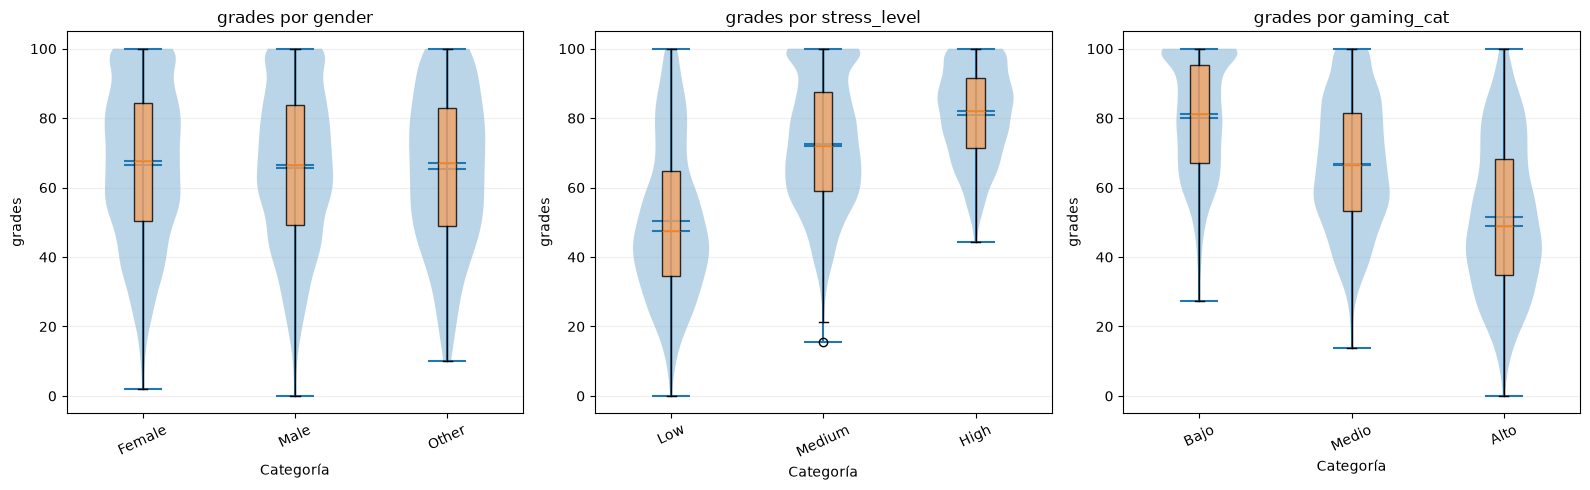

In [15]:
columnas_grupo = ['gender', 'stress_level', 'gaming_cat']

# Estos estadísticos permiten comparar rendimiento típico, variabilidad y rango dentro de cada grupo.
resumen_grupos = {}
for columna in columnas_grupo:
    resumen = df.groupby(columna, observed=True)['grades'].agg(
        cantidad='count',
        media='mean',
        mediana='median',
        desvio_estandar='std',
        minimo='min',
        maximo='max'
    )
    resumen['rango_intercuartilico'] = df.groupby(columna, observed=True)['grades'].quantile(0.75) - df.groupby(columna, observed=True)['grades'].quantile(0.25)
    resumen_grupos[columna] = resumen
    print(f'Estadísticos de grades por {columna}:')
    display(resumen.round(3))

# Cajas y violines muestran la distribución completa, no solo promedios por grupo.
fig, ejes = plt.subplots(1, len(columnas_grupo), figsize=(16, 5))
for eje, columna in zip(ejes, columnas_grupo):
    categorias = list(df[columna].dropna().unique())
    categorias = [categoria for categoria in df[columna].cat.categories if categoria in categorias] if hasattr(df[columna], 'cat') else categorias
    datos = [df.loc[df[columna] == categoria, 'grades'].dropna().to_numpy() for categoria in categorias]
    posiciones = np.arange(1, len(categorias) + 1)
    eje.violinplot(datos, positions=posiciones, showmeans=True, showmedians=True)
    eje.boxplot(datos, positions=posiciones, widths=0.12, patch_artist=True, boxprops={'facecolor': '#f4a261', 'alpha': 0.8})
    eje.set_xticks(posiciones, [str(categoria) for categoria in categorias], rotation=25)
    eje.set_title(f'grades por {columna}')
    eje.set_xlabel('Categoría')
    eje.set_ylabel('grades')
    eje.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### 4.4 Análisis bivariado: categórica frente a categórica

Este bloque es bivariado porque estudia la relación entre dos variables categóricas a la vez: `gender` frente a `stress_level`, `gender` frente a `gaming_cat` y `stress_level` frente a `gaming_cat`. Las tablas de contingencia muestran frecuencias absolutas, porcentajes condicionados por fila y porcentajes condicionados por columna.

In [16]:
# Cada tabla permite leer una perspectiva distinta de la asociación entre dos variables categóricas.
for indice, variable_filas in enumerate(columnas_categoricas):
    for variable_columnas in columnas_categoricas[indice + 1:]:
        tabla_absoluta = pd.crosstab(df[variable_filas], df[variable_columnas], dropna=False)
        tabla_por_fila = pd.crosstab(df[variable_filas], df[variable_columnas], normalize='index', dropna=False) * 100
        tabla_por_columna = pd.crosstab(df[variable_filas], df[variable_columnas], normalize='columns', dropna=False) * 100

        print(f'{variable_filas} frente a {variable_columnas}: frecuencias absolutas')
        display(tabla_absoluta)
        print(f'{variable_filas} frente a {variable_columnas}: porcentajes por fila')
        display(tabla_por_fila.round(2))
        print(f'{variable_filas} frente a {variable_columnas}: porcentajes por columna')
        display(tabla_por_columna.round(2))

gender frente a stress_level: frecuencias absolutas


stress_level,Low,Medium,High
gender,,,
Female,1328,1996,479
Male,1317,2090,497
Other,98,161,34


gender frente a stress_level: porcentajes por fila


stress_level,Low,Medium,High
gender,,,
Female,34.92,52.48,12.60
Male,33.73,53.53,12.73
Other,33.45,54.95,11.60


gender frente a stress_level: porcentajes por columna


...

gaming_cat,Bajo,Medio,Alto
stress_level,,,
Low,0,407,2336
Medium,2335,1912,0
High,336,348,326


stress_level frente a gaming_cat: porcentajes por fila


gaming_cat,Bajo,Medio,Alto
stress_level,,,
Low,0.00,14.84,85.16
Medium,54.98,45.02,0.00
High,33.27,34.46,32.28


stress_level frente a gaming_cat: porcentajes por columna


gaming_cat,Bajo,Medio,Alto
stress_level,,,
Low,0.00,15.26,87.75
Medium,87.42,71.69,0.00
High,12.58,13.05,12.25


### 4.5 Lectura integrada de resultados

- **Forma de las distribuciones:** las variables numéricas presentan asimetrías cercanas a cero; por eso, en general, la media y el desvío estándar son resúmenes razonables. `grades` tiene asimetría negativa moderada (`-0,283`) y un máximo acumulado en 100 por el tope aplicado, por lo que conviene acompañar la media con mediana e IQR. `grades_original` se conserva como referencia, pero no debe analizarse junto con `grades` en un mismo modelo porque son casi la misma variable.
- **Asociaciones numéricas:** `study_hours` muestra una asociación positiva importante con `grades` (Pearson ≈ 0,734; Spearman ≈ 0,742), mientras `gaming_hours` muestra una asociación negativa moderada (Pearson ≈ -0,558; Spearman ≈ -0,547). `sleep_hours` tiene una asociación positiva más débil (Pearson ≈ 0,245). Son asociaciones descriptivas y no demuestran causalidad.
- **Comparaciones por grupo:** el promedio de `grades` aumenta desde `gaming_cat=Alto` (≈ 51,40) a `Medio` (≈ 66,87) y `Bajo` (≈ 79,92). Por `stress_level`, el promedio es ≈ 50,50 en `Low`, ≈ 72,62 en `Medium` y ≈ 80,89 en `High`; este patrón debe interpretarse con cautela porque puede reflejar la forma en que se generó el dataset simulado y no una relación causal real.
- **Categorías:** `gender` está concentrado en `Male` (48,80%) y `Female` (47,54%), mientras `gaming_cat` está balanceada en aproximadamente un tercio por grupo. La tabla de contingencia revela una asociación estructural fuerte entre `stress_level` y `gaming_cat`: `Low` se concentra en `Alto` y `Medium` en `Bajo`, por lo que estas variables no deben interpretarse como independientes.
- **Tiempo:** no hay una variable de fecha u hora en el dataset. Por lo tanto, no se calculan media móvil, estacionalidad semanal/mensual ni quiebres temporales; esos análisis no son aplicables a esta fase.

## Sección 5. Análisis descriptivo y exploratorio
PENDIENTE.

## Sección 6. Conclusión de la Fase 1
PENDIENTE.